# Loading the data

## Data Loading Options

You can either:
1. Load the provided dataset (recommended): Read the .jsonl files from our GitHub repository.
2. Fetch fresh data: Uncomment the code below to rebuild the dataset from scratch (note: this process is time-consuming).

In [1]:
# Option 1: use the existing data files
posts_dir = "https://raw.githubusercontent.com/Stonej29/02805/main/Project/data/bluesky/posts_all.jsonl"
interactions_dir = "https://raw.githubusercontent.com/Stonej29/02805/main/Project/data/bluesky/interactions_all.jsonl"

In [ ]:
# Option 2: fetch data from Bluesky API (change username and password)

'''
from atproto import Client
from datetime import datetime, timezone
import json, time, math, logging
import os
from dateutil.parser import isoparse
from datetime import time as dt_time

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

# Suppress HTTP request logs from httpx/httpcore
logging.getLogger('httpx').setLevel(logging.WARNING)
logging.getLogger('httpcore').setLevel(logging.WARNING)

START = datetime(2025, 1, 1, 0, 0, tzinfo=timezone.utc) # Jan 1st
END   = datetime(2025, 2, 8, 0, 0, tzinfo=timezone.utc) # Feb 7th

POST_FILE  = 'posts.jsonl'
INTERACT_FILE= 'interactions.jsonl'
LOG_FILE   = 'all_read_dates.txt'

def safe_get(model, path, default=None):
    """walk dot-notation path safely:  safe_get(post, 'record.reply.parent.uri')"""
    for part in path.split('.'):
        model = getattr(model, part, None)
        if model is None:
            return default
    return model or default

def fetch_all_pages(endpoint, params):
    """generic cursor paginator that yields every item in endpoint(params)."""
    cursor = None
    while True:
        try:
            params['cursor'] = cursor
            rsp = endpoint(params)
            yield from getattr(rsp, 'feed', []) or getattr(rsp, 'likes', []) or getattr(rsp, 'reposted_by', [])
            cursor = getattr(rsp, 'cursor', None)
            if not cursor:
                break
            time.sleep(0.2)
        except Exception as e:
            logger.error(f'Paginator error: {e}')
            time.sleep(2)

def fetch_posts():
    """Fetch posts from START to END dates, storing posts and interactions"""
    total_posts = 0
    os.makedirs(os.path.dirname(LOG_FILE), exist_ok=True)
    log = open(LOG_FILE, 'w', encoding='utf8')

    # Initialize client
    logger.info('Initializing Bluesky client...')
    client = Client()
    
    with open("../credentials.json", "r", encoding="utf8") as f:
        creds = json.load(f)

    email = creds["email"]
    password = creds["password"]

    client.login(email, password)

    logger.info('Successfully logged in to Bluesky')

    # Base query terms
    query_terms = '(wildfire california) | (california evacuation) | (wildfire evacuation)'

    # Iterate day by day
    from datetime import timedelta
    current_day = START
    while current_day < END:
        next_day = current_day + timedelta(days=1)
        day_str = current_day.strftime('%Y-%m-%d')
        next_str = next_day.strftime('%Y-%m-%d')

        logger.info(f'Fetching posts for {day_str}...')
        cursor = None
        day_posts = 0

        # Paginate through all posts for this day
        while True:
            try:
                query = f'{query_terms} since:{day_str} until:{next_str}'
                rsp = client.app.bsky.feed.search_posts({'q': query, 'limit': 100, 'cursor': cursor})
            except Exception as e:
                logger.error(f'Search error: {e}')
                time.sleep(2)
                continue
            if not rsp.posts:
                break

            # Process all posts for the day
            for p in rsp.posts:
                ts = isoparse(p.record.created_at)  # robust parsing
                print(ts.date(), ts.time(), file=log)

                # ---------- core post row ----------
                row = {
                    "uri"          : p.uri,
                    "cid"          : p.cid,
                    "created_at"   : p.record.created_at,
                    "indexed_at"   : p.indexed_at,
                    "author_did"   : p.author.did,
                    "author_handle": p.author.handle,
                    "text"         : p.record.text,
                    "langs"        : getattr(p.record, 'langs', []),
                    "reply_to"     : safe_get(p, 'record.reply.parent.uri'),
                    "quoted"       : safe_get(p, 'record.embed.record.uri'),
                    "like_count"   : p.like_count or 0,
                    "repost_count" : p.repost_count or 0
                }
                with open(POST_FILE, 'a', encoding='utf8') as f:
                    f.write(json.dumps(row, ensure_ascii=False) + '\n')
                total_posts += 1
                day_posts += 1

                # Update progress on same line
                print(f'\r{day_str}: {day_posts} posts downloaded', end='', flush=True)

                # ---------- interaction rows ----------
                # 1) likes
                for like in fetch_all_pages(client.app.bsky.feed.get_likes,
                                            {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
                    with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                        f.write(json.dumps({
                            'src_did': like.actor.did,
                            'dst_uri': p.uri,
                            'edge'   : 'like'
                        }) + '\n')

                # 2) reposts
                for rep in fetch_all_pages(client.app.bsky.feed.get_reposted_by,
                                        {'uri': p.uri, 'cid': p.cid, 'limit': 100}):
                    with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                        f.write(json.dumps({
                            'src_did': rep.did,
                            'dst_uri': p.uri,
                            'edge'   : 'repost'
                        }) + '\n')

                # 3) replies (store the comment text too)
                try:
                    thread = client.app.bsky.feed.get_post_thread({'uri': p.uri, 'cid': p.cid, 'depth': 1})
                    for kid in (thread.thread.replies or []):
                        row = {
                            'src_did': kid.post.author.did,
                            'dst_uri': p.uri,
                            'edge': 'reply',
                            'reply_text': kid.post.record.text   # <-- children text
                        }
                        with open(INTERACT_FILE, 'a', encoding='utf8') as f:
                            f.write(json.dumps(row, ensure_ascii=False) + '\n')
                except Exception:
                    pass   # no thread / no replies

            cursor = getattr(rsp, 'cursor', None)
            if not cursor:
                break

        print()  # New line after day completes
        logger.info(f'Completed {day_str}: {day_posts} posts')
        current_day = next_day

    log.close()
    logger.info(f'Finished fetching data - Total posts: {total_posts}')
    logger.info(f'Interactions saved to: {INTERACT_FILE}')
    return

# Store data files in posts_dir and interactions_dir
posts_dir = POST_FILE
interactions_dir = INTERACT_FILE
'''

## Preprocessing the dataset

To ensure high-quality input for sentiment and network analysis, the raw dataset underwent the following preprocessing pipeline:

* **Language Filtering:** Applied `langdetect` to isolate English-language content (`en`), removing multilingual noise.
* **Text Normalization:** Text was lowercased and stripped of URLs, user mentions (`@`), emojis, and punctuation to focus on semantic content.
* **Stopwords Removal:** Standard English stopwords (NLTK) were removed to reduce noise.
* **Spam/Bot Removal:** A regex filter targeted and removed automated "scanner" and "dispatch" feed posts (e.g., "live audio feed").
* **Consistency & Deduplication:** Duplicate posts were removed by URI. The interactions dataset was strictly filtered to include only edges (replies, reposts, likes) pointing to the remaining valid posts, ensuring graph integrity.

In [ ]:
import pandas as pd
from langdetect import detect
import re, string, nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_en = set(stopwords.words('english'))

def preprocess_posts_and_interactions(posts_file="../data/bluesky/ca_fire_20250101_20250207.jsonl", interact_file="../data/bluesky/interactions_20250101_20250207.jsonl"):
    """Preprocess posts and interactions from given jsonl files."""
    # ---------- load ----------
    posts  = pd.read_json(posts_file, lines=True)
    interact = pd.read_json(interact_file, lines=True)

    # ---------- language detection ----------
    def detect_language(text):
        try:
            return detect(text)
        except:
            return 'unknown'

    posts['langs'] = posts['text'].apply(detect_language)

    # ---------- filter to English only ----------
    posts = posts[posts['langs'] == 'en'].reset_index(drop=True)

    # ---------- regexes & cleaning fn (kept from your original) ----------
    url_re   = re.compile(r'https?://\S+')
    # NOTE: keep hashtag removal or not depending on whether you want to preserve hashtags
    mention_re = re.compile(r'[@#]\w+')
    emoji_re = re.compile("["                                
        u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF" u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF" u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    scanner_re = re.compile(r'\b(?:live audio feed|/webplayer/)\b')

    def clean(text):
        if not isinstance(text, str):
            return ''
        t = text.lower()
        t = url_re.sub(' ', t)
        t = mention_re.sub(' ', t)
        t = emoji_re.sub(' ', t)
        t = scanner_re.sub(' ', t)
        tokens = [w for w in t.split() if w not in stop_en and w not in string.punctuation]
        return ' '.join(tokens)

    # ---------- apply cleaning ----------
    posts['clean_text'] = posts['text'].apply(clean)

    # ---------- drop scanner spam ----------
    posts = posts[~posts['clean_text'].str.contains(
        r'live audio feed|/webplayer/|dispatch[\s,]*\d+(?:[,\s]+\d+)*', na=False)]

    # ---------- deduplicate by URI ----------
    # keep the first occurrence of each unique post URI
    before_rows = len(posts)
    posts = posts.drop_duplicates(subset='uri', keep='first').reset_index(drop=True)
    after_rows = len(posts)

    # ---------- create sets of unique URIs ----------
    posts_uris = set(posts['uri'].dropna())
    interacted_dst_uris_all = set(interact['dst_uri'].dropna())

    # ---------- interactions that point to posts *we have* ----------
    interacted_in_dataset = interacted_dst_uris_all & posts_uris

    # ---------- lonely posts (unique posts with zero interactions in our filtered interactions) ----------
    lonely_uris = posts_uris - interacted_in_dataset

    # ---------- optionally, filter interactions to only those relevant to our post-set ----------
    interact_filtered = interact[interact['dst_uri'].isin(posts_uris)].copy()

    # ---------- compute user set (authors in posts + sources of interactions that we kept) ----------
    users = set(posts['author_did'].dropna()) | set(interact_filtered['src_did'].dropna())

    # ---------- print summary stats (consistent) ----------
    print("=== dataset cleaning & dedupe ===")
    print(f"Rows after scanning-spam filter (before dedupe): {before_rows}")
    print(f"Rows after dedupe by uri: {after_rows}")
    print()

    print("=== URI / interaction summary (unique-URI basis) ===")
    total_unique_posts = len(posts_uris)
    print(f"Total unique clean posts: {total_unique_posts:,}")
    print(f"Unique post URIs that appear as interaction targets (in our interact file): {len(interacted_in_dataset):,}")
    print(f"Unique post URIs with zero interactions: {len(lonely_uris):,}")
    print(f"Check sum (unique targets + lonely) == total_unique_posts -> "
        f"{len(interacted_in_dataset) + len(lonely_uris)} == {total_unique_posts}")
    print()

    print("=== interactions (filtered to posts we retained) ===")
    print(f"Total interaction rows (original interactions file): {len(interact):,}")
    print(f"Interaction rows after filtering to dst_uri in our posts: {len(interact_filtered):,}")
    print("Interaction types (filtered):")
    if 'edge' in interact_filtered.columns:
        counts = interact_filtered['edge'].value_counts()
        for t, n in counts.items():
            print(f"{t:8s}: {n:,}")
    else:
        print("No 'edge' column found in interactions dataframe.")

    print()
    print(f"Distinct users (authors in posts ∪ src_did of filtered interactions): {len(users):,}")

    # ---------- show first 10 cleaned posts for inspection ----------
    print()
    print("=== first 10 cleaned posts (after filtering & dedupe) ===")
    with pd.option_context('display.max_colwidth', None):
        print(posts['clean_text'].head(10).to_string(index=False))

    return posts, interact_filtered

In [8]:
posts, interactions = preprocess_posts_and_interactions(posts_dir, interactions_dir)

=== dataset cleaning & dedupe ===
Rows after scanning-spam filter (before dedupe): 8839
Rows after dedupe by uri: 8836

=== URI / interaction summary (unique-URI basis) ===
Total unique clean posts: 8,836
Unique post URIs that appear as interaction targets (in our interact file): 5,267
Unique post URIs with zero interactions: 3,569
Check sum (unique targets + lonely) == total_unique_posts -> 8836 == 8836

=== interactions (filtered to posts we retained) ===
Total interaction rows (original interactions file): 403,598
Interaction rows after filtering to dst_uri in our posts: 368,985
Interaction types (filtered):
like    : 282,682
repost  : 77,339
reply   : 8,964

Distinct users (authors in posts ∪ src_did of filtered interactions): 182,086

=== first 10 cleaned posts (after filtering & dedupe) ===
                                                                                                                           “california require insurers offer home coverage wildfire-prone areas

# Network analysis

In [9]:
import networkx as nx
import pandas as pd
from pathlib import Path
from collections import defaultdict

In [10]:
print(f"Loaded {len(posts)} posts and {len(interactions)} interactions")

Loaded 8836 posts and 368985 interactions


## Helper Functions

In [11]:
def create_uri_to_author_mapping(posts):
    """Map post URIs to author DIDs"""
    post_to_author = {}
    for _, row in posts.iterrows():
        post_to_author[row['uri']] = row['author_did']
    return post_to_author


def create_did_to_handle_mapping(posts):
    """Map author DIDs to handles"""
    did_to_handle = {}
    for _, row in posts.iterrows():
        if 'author_did' in row and 'author_handle' in row:
            did_to_handle[row['author_did']] = row['author_handle']
    return did_to_handle

## Build Reply-Only Network

In [12]:
def build_replies_only_graph(posts, interactions):
    """Build network using ONLY reply interactions (no likes or reposts)"""
    post_to_author = create_uri_to_author_mapping(posts)
    did_to_handle = create_did_to_handle_mapping(posts)
    
    # Build directed graph
    G_directed = nx.DiGraph()
    interaction_counts = defaultdict(int)
    
    # Filter for replies only, count interactions
    for _, interaction in interactions.iterrows():
        if interaction['edge'] != 'reply':
            continue
            
        src_user = interaction['src_did']
        dst_post = interaction['dst_uri']
        
        if dst_post in post_to_author:
            dst_user = post_to_author[dst_post]
            
            # No self loops
            if src_user != dst_user:
                interaction_counts[(src_user, dst_user)] += 1
    
    # Add edges with weights
    for (src, dst), count in interaction_counts.items():
        G_directed.add_edge(src, dst, weight=count, replies=count)
    
    # Add node attributes
    for node in G_directed.nodes():
        G_directed.nodes[node]['in_degree'] = G_directed.in_degree(node)
        G_directed.nodes[node]['out_degree'] = G_directed.out_degree(node)
        if node in did_to_handle:
            G_directed.nodes[node]['author_handle'] = did_to_handle[node]
    
    # Create undirected version
    G_undirected = G_directed.to_undirected()
    
    # Add node attributes to undirected graph
    for node in G_undirected.nodes():
        G_undirected.nodes[node]['in_degree'] = G_directed.in_degree(node)
        G_undirected.nodes[node]['out_degree'] = G_directed.out_degree(node)
        G_undirected.nodes[node]['degree'] = G_undirected.degree(node)
        if node in did_to_handle:
            G_undirected.nodes[node]['author_handle'] = did_to_handle[node]
    
    print(f"Directed: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
    print(f"Undirected: {G_undirected.number_of_nodes()} nodes, {G_undirected.number_of_edges()} edges")
    
    return G_directed, G_undirected

## Create Graphs

In [13]:
G_directed, G_undirected = build_replies_only_graph(posts, interactions)

Directed: 8094 nodes, 7801 edges
Undirected: 8094 nodes, 7801 edges


## Save Graphs

In [14]:
nx.write_gml(G_directed, "user_interaction_graph_directed.gml")
nx.write_gml(G_undirected, "user_interaction_graph_undirected.gml")
print("Graphs saved")

Graphs saved


## Network Statistics

In [15]:
import numpy as np

G = G_undirected # we use the undirected from here on

### Basic Properties

In [16]:
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Density: {nx.density(G):.6f}")

Nodes: 8,094
Edges: 7,801
Density: 0.000238


### Degree Statistics

In [17]:
degrees = [d for n, d in G.degree()]

print(f"Mean degree: {np.mean(degrees):.2f}")
print(f"Median degree: {np.median(degrees):.2f}")
print(f"Std degree: {np.std(degrees):.2f}")
print(f"Max degree: {np.max(degrees)}")
print(f"Min degree: {np.min(degrees)}")

Mean degree: 1.93
Median degree: 1.00
Std degree: 13.84
Max degree: 791
Min degree: 1


### Connectivity

In [18]:
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)

print(f"Number of components: {len(components)}")
print(f"Largest component size: {len(largest_cc):,} ({len(largest_cc)/G.number_of_nodes():.2%})")

Number of components: 697
Largest component size: 6,104 (75.41%)


### Assortativity

In [19]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity: {assortativity:.4f}")

Degree assortativity: -0.2315


### Top Nodes by Degree Centrality

In [20]:
degree_centrality = nx.degree_centrality(G)
top_degree_cent = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by degree centrality:")
for node, score in top_degree_cent:
    handle = G.nodes[node].get('author_handle', 'unknown')
    print(f"  {handle}: {score:.4f}")

Top 5 nodes by degree centrality:
  artcandee.bsky.social: 0.0977
  patriottakes.bsky.social: 0.0696
  governor.ca.gov: 0.0586
  npr.org: 0.0236
  aaronparnas.bsky.social: 0.0217


### Top Nodes by Betweenness Centrality

In [21]:
betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by betweenness centrality:")
for node, score in top_betweenness:
    handle = G.nodes[node].get('author_handle', 'unknown')
    print(f"  {handle}: {score:.4f}")

Top 5 nodes by betweenness centrality:
  artcandee.bsky.social: 0.2687
  governor.ca.gov: 0.1417
  patriottakes.bsky.social: 0.1384
  npr.org: 0.0466
  juddlegum.bsky.social: 0.0417


## Louvain Community Detection

In [22]:
import community as community_louvain

### Run Louvain Algorithm

In [23]:
# Extract gcc
G_gcc = G.subgraph(largest_cc).copy()
coverage = (G_gcc.number_of_nodes() / G.number_of_nodes()) * 100
print(f"Running Louvain on GCC: {G_gcc.number_of_nodes()} nodes, {G_gcc.number_of_edges()} edges ({coverage:.1f}% of network)")

communities = community_louvain.best_partition(G_gcc, weight='weight', random_state=42)

# Add community assignments to nodes
for node, comm_id in communities.items():
    G_gcc.nodes[node]['community'] = comm_id

print(f"Found {len(set(communities.values()))} communities")

Running Louvain on GCC: 6104 nodes, 6507 edges (75.4% of network)
Found 57 communities


### Community Statistics

In [24]:
from collections import Counter

# Count community sizes
comm_sizes = Counter(communities.values())

print(f"Number of communities: {len(comm_sizes)}")
print(f"Mean community size: {np.mean(list(comm_sizes.values())):.2f}")
print(f"Median community size: {np.median(list(comm_sizes.values())):.2f}")
print(f"Largest community: {max(comm_sizes.values())} nodes")
print(f"Smallest community: {min(comm_sizes.values())} node(s)")

Number of communities: 57
Mean community size: 107.09
Median community size: 79.00
Largest community: 694 nodes
Smallest community: 7 node(s)


### Modularity

In [25]:
from networkx.algorithms.community import modularity as nx_modularity

comm_dict = defaultdict(set)
for node, comm_id in communities.items():
    comm_dict[comm_id].add(node)
communities_list = list(comm_dict.values())

modularity = nx_modularity(G_gcc, communities_list)
print(f"Modularity: {modularity:.4f}")

Modularity: 0.8902


### Top Communities by Size

In [26]:
top_communities = comm_sizes.most_common(10)

print("Top 10 communities by size:")
for comm_id, size in top_communities:
    print(f"Community {comm_id}: {size} nodes")

Top 10 communities by size:
Community 4: 694 nodes
Community 11: 530 nodes
Community 7: 436 nodes
Community 8: 208 nodes
Community 9: 180 nodes
Community 12: 179 nodes
Community 24: 178 nodes
Community 19: 175 nodes
Community 20: 170 nodes
Community 37: 165 nodes


### Save Communities

In [27]:
import json

# Save community assignments
with open("louvain_communities.json", 'w') as f:
    json.dump(communities, f, indent=2)

print("Communities saved")

Communities saved


## Sentiment by Community

In [28]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

### Compute Sentiment Scores

In [29]:
analyzer = SentimentIntensityAnalyzer()
posts['sentiment'] = posts['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
print(f"Computed sentiment for {len(posts)} posts")

Computed sentiment for 8836 posts


### Map Posts to Communities

In [30]:
# Map author DIDs to communities
node_community = {}
for node in G_gcc.nodes():
    comm_id = G_gcc.nodes[node].get('community')
    if comm_id is not None:
        node_community[node] = comm_id

posts['community'] = posts['author_did'].map(node_community)
community_posts = posts.dropna(subset=['community'])
community_posts['community'] = community_posts['community'].astype(int)

print(f"Mapped {len(community_posts)} posts to communities")

Mapped 1340 posts to communities


/tmp/ipykernel_8913/2984680034.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  community_posts['community'] = community_posts['community'].astype(int)


### Aggregate Sentiment by Community

In [31]:
# Aggregate sentiment by community
sentiment_stats = community_posts.groupby('community')['sentiment'].agg(['mean', 'std', 'count'])

# Filter to communities with at least 10 posts for better accuracy
min_posts = 10
sentiment_stats = sentiment_stats[sentiment_stats['count'] >= min_posts]

# Calculate standard error of mean
sentiment_stats['sem'] = sentiment_stats['std'] / np.sqrt(sentiment_stats['count'])

print(f"Communities with at least {min_posts} posts: {len(sentiment_stats)}")

Communities with at least 10 posts: 35


### Add Community Metadata

In [32]:
# Add node counts and leaders
comm_nodes = defaultdict(list)
for node in G_gcc.nodes():
    comm_id = G_gcc.nodes[node].get('community')
    if comm_id is not None:
        degree = G_gcc.degree(node)
        handle = G_gcc.nodes[node].get('author_handle', 'Unknown')
        comm_nodes[comm_id].append((degree, handle))

# Add to stats
leaders = []
node_counts = []
for comm_id in sentiment_stats.index:
    nodes = comm_nodes.get(comm_id, [])
    node_counts.append(len(nodes))
    if nodes:
        _, handle = max(nodes, key=lambda x: x[0])
        leaders.append(handle)
    else:
        leaders.append("Unknown")

sentiment_stats['leader'] = leaders
sentiment_stats['node_count'] = node_counts

### Top Communities by Size with Sentiment

In [33]:
print("Top 10 communities by node count:")
top_10 = sentiment_stats.sort_values('node_count', ascending=False).head(10)
print(top_10[['node_count', 'count', 'mean', 'sem', 'leader']])

Top 10 communities by node count:
           node_count  count      mean       sem                    leader
community                                                                 
4                 694     50 -0.025074  0.083936     artcandee.bsky.social
11                530     55 -0.121467  0.069597  patriottakes.bsky.social
7                 436     53 -0.062651  0.070003           governor.ca.gov
8                 208     28 -0.182304  0.090938                   npr.org
9                 180     23 -0.112861  0.088650    georebekah.bsky.social
12                179     27 -0.331344  0.098799            astrokatie.com
24                178     12 -0.165867  0.142999     juddlegum.bsky.social
19                175     14 -0.291921  0.147568       governorwalz.mn.gov
20                170     15 -0.002207  0.192687      droddman.bsky.social
37                165     22 -0.068273  0.088697   aaronparnas.bsky.social


## Community Visualization (cuGraph GPU)

In [ ]:
import cugraph
import cudf
import matplotlib.pyplot as plt

### Prepare Graph for GPU Layout

In [ ]:
# Filter to top communities for visualization
top_n = 10
comm_counts = {}
for n in G_gcc.nodes():
    c = G_gcc.nodes[n].get('community', 0)
    comm_counts[c] = comm_counts.get(c, 0) + 1

sorted_comms = sorted(comm_counts.items(), key=lambda x: x[1], reverse=True)
top_comms = {c for c, _ in sorted_comms[:top_n]}

G_viz = G_gcc.subgraph([n for n in G_gcc.nodes() if G_gcc.nodes[n].get('community', 0) in top_comms]).copy()
print(f"Visualizing top {top_n} communities: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges")

Visualizing top 10 communities: 2915 nodes, 3025 edges


### Compute Force Atlas 2 Layout (GPU)

In [ ]:
# Map string node IDs to integers
node_list = list(G_viz.nodes())
node_to_int = {node: i for i, node in enumerate(node_list)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Build edge DataFrame
edge_data = [(node_to_int[u], node_to_int[v], float(d.get('weight', 1.0))) 
             for u, v, d in G_viz.edges(data=True)]
edge_df = cudf.DataFrame(edge_data, columns=['src', 'dst', 'weight'])

cu_G = cugraph.Graph()
cu_G.from_cudf_edgelist(edge_df, source='src', destination='dst', edge_attr='weight')

pos_df = cugraph.layout.force_atlas2(
    cu_G,
    max_iter=5000,
    outbound_attraction_distribution=False,
    lin_log_mode=True,
    edge_weight_influence=3.0,
    jitter_tolerance=1.0,
    barnes_hut_optimize=True,
    barnes_hut_theta=0.8,
    scaling_ratio=10.0,
    gravity=5.0
)

# Convert to CPU
pos_df_host = pos_df.to_pandas()
pos_map = {row.vertex: (float(row.x), float(row.y)) 
           for row in pos_df_host.itertuples(index=False)}
positions = {int_to_node[idx]: pos_map[idx] for idx in int_to_node if idx in pos_map}

print("Layout computed")

Layout computed


### Visualize Communities

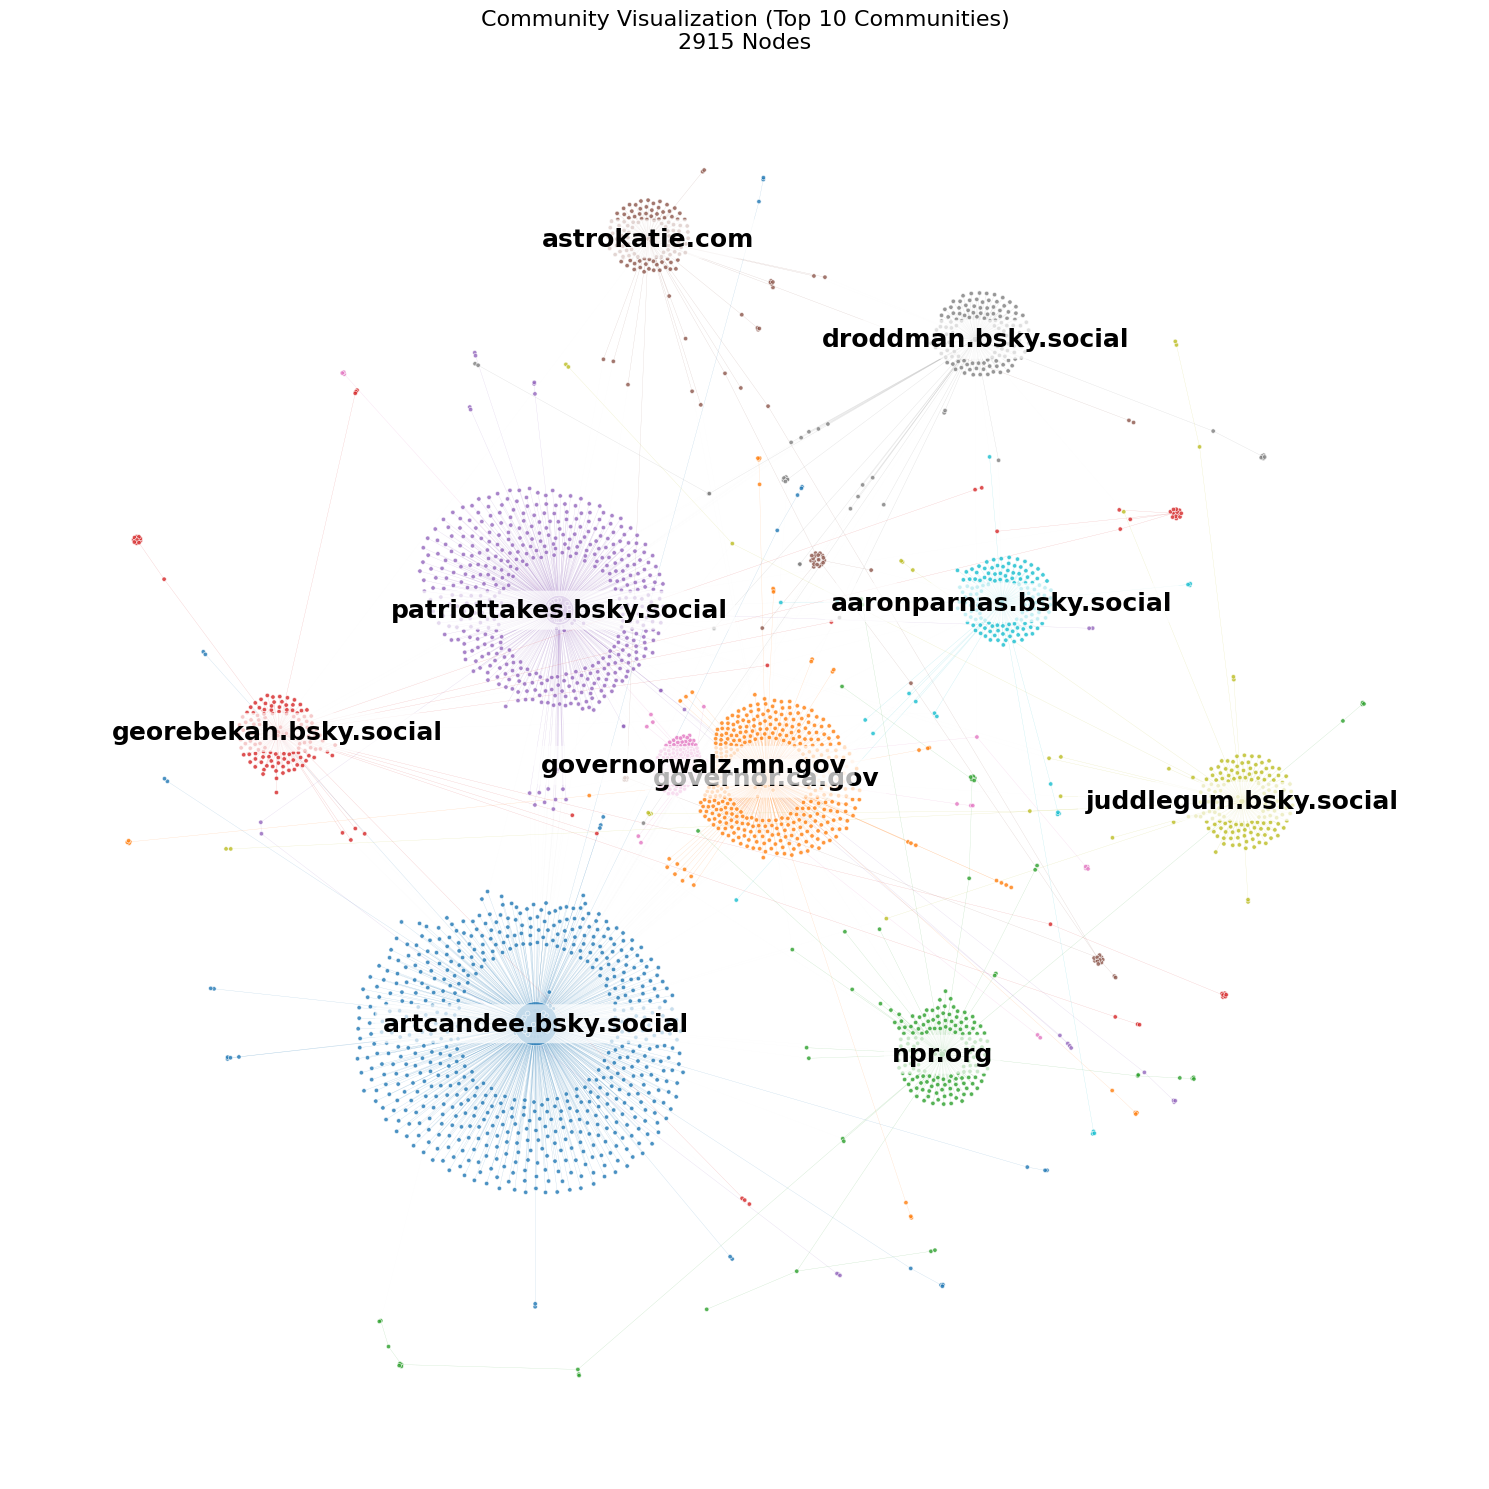

In [ ]:
nodes_iter = list(G_viz.nodes())

# Get communities and node sizes
communities_viz = [int(G_viz.nodes[n].get('community', 0)) for n in nodes_iter]
node_interactions = dict(G_viz.degree(weight='weight'))

# Node sizes based on interactions
sizes_raw = np.array([node_interactions.get(n, 1) for n in nodes_iter])
norm = (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min() + 1e-9)
sizes_final = (norm ** 3 * 990 + 10)

# Color mapping
unique_comm_ids = sorted(set(communities_viz))
comm_to_idx = {comm_id: idx for idx, comm_id in enumerate(unique_comm_ids)}
community_indices = [comm_to_idx[c] for c in communities_viz]
cmap = plt.colormaps.get_cmap('tab10').resampled(len(unique_comm_ids))

# Find top node in each community for labels
top_nodes = {}
for n in nodes_iter:
    c = G_viz.nodes[n].get('community', 0)
    score = node_interactions.get(n, 0)
    if c not in top_nodes or score > top_nodes[c][1]:
        top_nodes[c] = (n, score)

labels_to_draw = {}
for c, (n, _) in top_nodes.items():
    handle = G_viz.nodes[n].get('author_handle', n)
    labels_to_draw[n] = handle

# Plot
plt.figure(figsize=(15, 15))

# Separate edges by community
valid_edges = [(u, v) for u, v in G_viz.edges() if u in positions and v in positions]
edge_weights = np.array([G_viz[u][v].get('weight', 1.0) for u, v in valid_edges])
if len(edge_weights) > 0 and edge_weights.max() > edge_weights.min():
    weight_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min())
    edge_widths = weight_norm * 2.8 + 0.2
else:
    edge_widths = np.ones(len(valid_edges))

# Separate intra-community and inter-community edges
intra_comm_edges = {}
inter_comm_edges = []
inter_comm_widths = []

for idx, (u, v) in enumerate(valid_edges):
    comm_u = G_viz.nodes[u].get('community', 0)
    comm_v = G_viz.nodes[v].get('community', 0)
    
    if comm_u == comm_v:
        # Intra-community edge
        if comm_u not in intra_comm_edges:
            intra_comm_edges[comm_u] = []
        intra_comm_edges[comm_u].append((u, v, edge_widths[idx]))
    else:
        # Inter-community edge
        inter_comm_edges.append((u, v))
        inter_comm_widths.append(edge_widths[idx] * 0.5)

# Draw inter-community edges first (gray, faint)
if inter_comm_edges:
    nx.draw_networkx_edges(G_viz, positions, edgelist=inter_comm_edges,
                          alpha=0.05, edge_color='gray', arrows=False, width=inter_comm_widths)

# Draw intra-community edges with community colors
for comm_id, edge_data in intra_comm_edges.items():
    color_idx = comm_to_idx[comm_id]
    color = cmap(color_idx)
    edges = [(u, v) for u, v, _ in edge_data]
    widths = [w for _, _, w in edge_data]
    nx.draw_networkx_edges(G_viz, positions, edgelist=edges,
                          alpha=0.3, edge_color=color, arrows=False, width=widths)

# Draw nodes
nx.draw_networkx_nodes(G_viz, positions, node_size=sizes_final.tolist(),
                      node_color=community_indices, cmap=cmap, alpha=0.8,
                      linewidths=0.5, edgecolors='white')

# Draw labels
nx.draw_networkx_labels(G_viz, positions, labels_to_draw,
                       font_size=18, font_color='black', font_weight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))

plt.title(f'Community Visualization (Top {top_n} Communities)\n{G_viz.number_of_nodes()} Nodes', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

_**Fig. 1:** Force Atlas 2 (FA2) layout visualization of the network structure, generated using cuGraph. The subgraph contains the top 10 largest communities within the dataset. Edge density illustrates the strength of connections, with prominent central nodes such as artcandee (blue) and patriottakes (purple) serving as key bridges between distinct clusters._

# Text-based analysis

## Exploratory Keyword Analysis (TF-IDF)

We initially employed **Term Frequency-Inverse Document Frequency (TF-IDF)** to identify distinct keywords for each disaster phase. However, these results were excluded from the final report in favor of the **Topic Modeling analysis (BERTopic)** presented in the next section, which provided richer semantic context and more coherent narrative clusters than isolated keywords.

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud

# --- TF-IDF Setup ---
DOMAIN_STOPWORDS = {
    "california", "wildfire", "wildfires", "fire", "fires", "los", "angeles",
    "bluesky", "bsky", "post", "posts", "click", "tap", "trending",
    "www", "http", "https", "com", "co", "amp",
    "like", "just", "really", "going", "got", "get", "know", "think",
    "want", "need", "see", "say", "said", "says", "make", "made",
    "way", "thing", "things", "time", "year", "years", "day", "days",
    "people", "new", "good", "right", "don", "didn", "doesn", "won",
    "isn", "aren", "wasn", "weren", "let", "ll", "ve", "re",
}

def compute_tfidf(texts, max_features=2000, min_df=2, max_df=0.8, ngram_range=(1, 1)):
    """Compute TF-IDF scores, return {term: score} dict."""
    stopwords = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))
    vectorizer = TfidfVectorizer(
        max_features=max_features, min_df=min_df, max_df=max_df,
        ngram_range=ngram_range, stop_words=stopwords,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]{2,}\b",
    )
    try:
        X = vectorizer.fit_transform(texts)
        if X.shape[0] == 0 or X.shape[1] == 0:
            return {}
        scores = np.asarray(X.mean(axis=0)).ravel()
        return dict(zip(vectorizer.get_feature_names_out(), scores))
    except ValueError:
        return {}

def make_wordcloud(scores, title="", max_words=150, width=800, height=500, ax=None):
    """Generate wordcloud from TF-IDF scores."""
    if not scores:
        return None
    
    merged = {k.strip().lower(): max(v, scores.get(k, 0)) for k, v in scores.items() if isinstance(k, str)}
    wc = WordCloud(
        width=width, height=height, background_color="white",
        max_words=max_words, colormap="viridis", repeat=False,
    ).generate_from_frequencies(merged)
    
    if ax is None:
        plt.figure(figsize=(10, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, fontsize=14, fontweight="bold")
        plt.tight_layout()
    else:
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title, fontsize=11, fontweight="bold")
    return wc

In [50]:
# Define time periods
periods = {
    "Jan 1-6": ("2025-01-01", "2025-01-06"),
    "Jan 7-13": ("2025-01-07", "2025-01-13"),
    "Jan 14-21": ("2025-01-14", "2025-01-21"),
    "Jan 22-31": ("2025-01-22", "2025-01-31"),
    "Feb 1-7": ("2025-02-01", "2025-02-07"),
}
periods = {k: (pd.to_datetime(v[0]).date(), pd.to_datetime(v[1]).date()) for k, v in periods.items()}

# Compute TF-IDF per period
period_scores, period_counts = {}, {}
for label, (start, end) in periods.items():
    mask = (posts["date_only"] >= start) & (posts["date_only"] <= end)
    group = posts[mask]
    period_counts[label] = len(group)
    period_scores[label] = compute_tfidf(group["clean_text"].tolist(), min_df=1, ngram_range=(1, 2)) if len(group) > 0 else {}
    print(f"{label}: {len(group):,} posts, {len(period_scores[label]):,} terms")

Jan 1-6: 60 posts, 1,177 terms
Jan 7-13: 4,602 posts, 2,000 terms
Jan 14-21: 1,746 posts, 2,000 terms
Jan 22-31: 1,354 posts, 2,000 terms
Feb 1-7: 242 posts, 2,000 terms


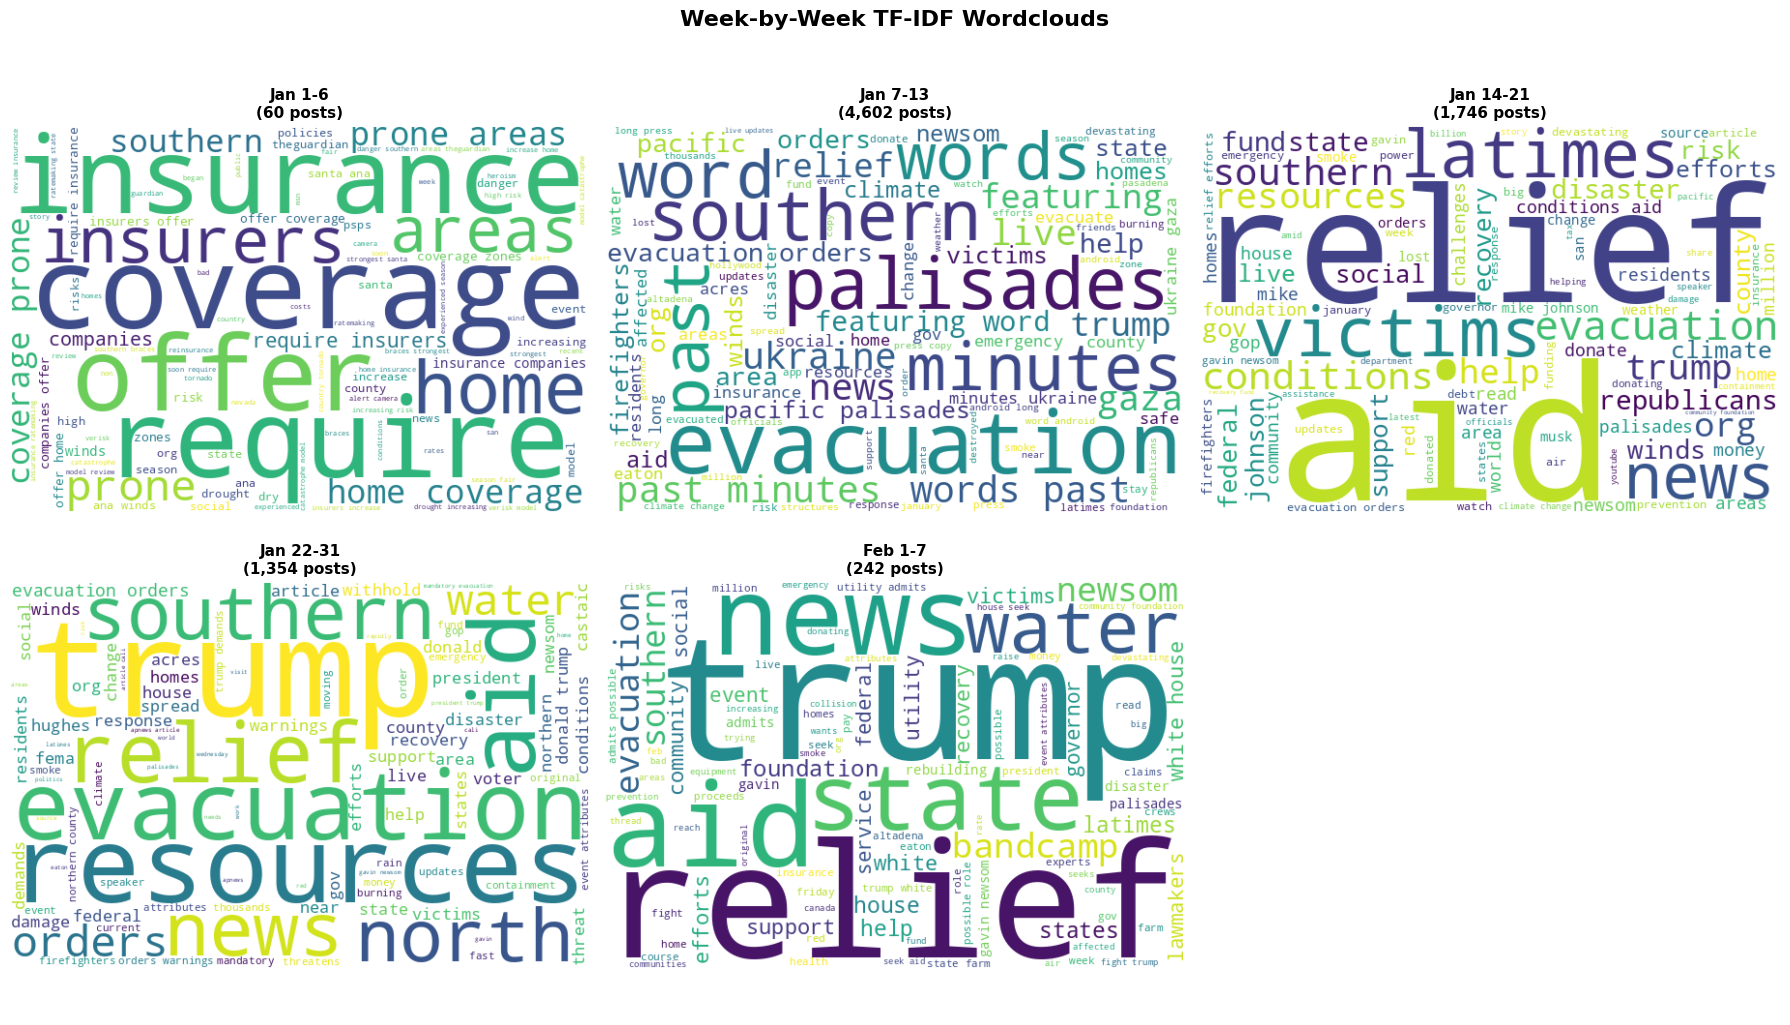

In [51]:
# Create 5-panel wordcloud collage
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, label in enumerate(periods.keys()):
    scores = period_scores.get(label, {})
    title = f"{label}\n({period_counts[label]:,} posts)"
    if scores:
        make_wordcloud(scores, title=title, max_words=100, width=600, height=400, ax=axes[idx])
    else:
        axes[idx].text(0.5, 0.5, "No data", ha="center", va="center", fontsize=14)
        axes[idx].set_title(title, fontsize=11, fontweight="bold")
        axes[idx].axis("off")

axes[5].axis("off")  # Hide 6th subplot

plt.suptitle("Week-by-Week TF-IDF Wordclouds", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("weekly_wordcloud_collage.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

_**Fig. 2:** Temporal evolution of emotional composition and thematic discourse categories on Bluesky during the January 2025 California wildfires._

## Topic Modeling with BERTopic

We employed **BERTopic** to extract latent thematic clusters from the dataset unsupervised.

* **Stopword Filtering:** A robust custom exclusion list was applied to remove generic geographical terms (e.g., "California", "LA"), platform-specific noise ("bluesky", "thread"), and web artifacts, ensuring topics represent distinct narratives rather than general context.
* **Model Architecture:** The pipeline utilizes **UMAP** for dimensionality reduction (5 components, cosine metric) and a **CountVectorizer** for class-based TF-IDF representation.
* **Execution:** The model dynamically identifies coherent topic clusters (`min_topic_size=15`) across the corpus, assigning a dominant topic ID to each post for granular analysis.

### Overall topic analysis

In [34]:
import umap
from bertopic import BERTopic
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# --- BERTopic Setup ---
# Universal domain stopwords (merged from all sources)
DOMAIN_STOPWORDS = {
    # Fire/location terms (too common, not discriminative)
    "california", "wildfire", "wildfires", "fire", "fires", "los", "angeles",
    "la", "palisades", "eaton", "altadena", "malibu", "pacific",
    
    # Social media noise
    "bluesky", "bsky", "post", "posts", "click", "tap", "trending", "app",
    "twitter", "tweet", "retweet", "thread", "follow", "followers",
    
    # Web artifacts
    "www", "http", "https", "com", "co", "amp", "org", "net",
    
    # Common filler words
    "like", "just", "really", "going", "got", "get", "know", "think",
    "want", "need", "see", "say", "said", "says", "make", "made",
    "way", "thing", "things", "time", "year", "years", "day", "days",
    "people", "new", "good", "right", "lot", "much", "many", "even",
    "still", "back", "now", "today", "tonight", "yesterday", "tomorrow",
    "one", "two", "first", "last", "every", "also",
    
    # Contractions remnants
    "don", "didn", "doesn", "won", "isn", "aren", "wasn", "weren", 
    "let", "ll", "ve", "re", "can", "could", "would", "should",
    
    # Other noise
    "android", "featuring", "press", "youtube", "gaza", "ukrainian",
    "words", "word",
}

ALL_STOPWORDS = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))

def create_topic_model(texts, min_topic_size=10):
    """Create and fit a BERTopic model on texts."""
    if len(texts) < 5:
        return None, None, None
    
    n_neighbors = min(15, len(texts) - 1)
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )
    
    vectorizer_model = CountVectorizer(stop_words=ALL_STOPWORDS)
    
    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        low_memory=True,
        umap_model=umap_model,
        min_topic_size=min(min_topic_size, max(5, len(texts) // 10)),
        verbose=False
    )
    
    topics, probs = topic_model.fit_transform(texts)
    return topic_model, topics, probs

def display_topics(topic_model, n_topics=10):
    """Display top topics from a BERTopic model."""
    if topic_model is None:
        print("No topic model available.")
        return None
    
    topic_info = topic_model.get_topic_info()
    print(f"\nFound {len(topic_info) - 1} topics (excluding outliers)")
    print("\nTop Topics:")
    print(topic_info.head(n_topics + 1).to_string(index=False))
    return topic_info

/home/jyanes/socialgraphs_2025/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Run BERTopic on all posts
mask_all = posts['clean_text'].str.strip().ne("")
texts_all = posts.loc[mask_all, 'clean_text'].tolist()

print(f"Running BERTopic on {len(texts_all):,} posts...")
topic_model_all, topics_all, probs_all = create_topic_model(texts_all, min_topic_size=15)

if topic_model_all is not None:
    posts.loc[mask_all, 'topic_overall'] = topics_all
    
    print("\n" + "="*60)
    print("OVERALL TOPIC ANALYSIS - California Wildfires on Bluesky")
    print("="*60)
    topic_info_all = display_topics(topic_model_all, n_topics=15)

Running BERTopic on 8,793 posts...

OVERALL TOPIC ANALYSIS - California Wildfires on Bluesky

Found 103 topics (excluding outliers)

Top Topics:
 Topic  Count                                    Name                                                                                        Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [36]:
# Visualize overall topics - Bar chart
if topic_model_all is not None:
    fig = topic_model_all.visualize_barchart(top_n_topics=10, n_words=8, height=400)
    fig.write_html(str("overall_topics_barchart.html"))
    fig.show()

_**Fig. 3**: Detailed results of the BERTopic analysis for the California wildfires discourse. Top 10 topics are presented, together with their characteristic words._

### Period-wise topic analysis

In [39]:
# Define time periods (same as wordcloud analysis)
periods = {
    "Jan 1-6": ("2025-01-01", "2025-01-06"),
    "Jan 7-21": ("2025-01-07", "2025-01-21"),
    "Jan 22-31": ("2025-01-22", "2025-01-31"),
    "Feb 1-7": ("2025-02-01", "2025-02-07"),
}
periods = {k: (pd.to_datetime(v[0]).date(), pd.to_datetime(v[1]).date()) for k, v in periods.items()}
posts["created_at"] = pd.to_datetime(posts["created_at"], errors='coerce', utc=True)
posts["date_only"] = posts["created_at"].dt.date

# Use the OVERALL model to get consistent topics across all periods
# This ensures the same 10 topics are tracked throughout
print("Using overall topic model for consistent topic tracking across periods...")
print(f"Total topics in overall model: {len(topic_model_all.get_topic_info()) - 1} (excluding outliers)")

# Count posts per period
period_counts = {}
for label, (start, end) in periods.items():
    # Handle NaT values
    mask = posts["date_only"].notna() & (posts["date_only"] >= start) & (posts["date_only"] <= end)
    period_counts[label] = mask.sum()
    print(f"\n{label}: {period_counts[label]:,} posts")

Using overall topic model for consistent topic tracking across periods...
Total topics in overall model: 103 (excluding outliers)

Jan 1-6: 60 posts

Jan 7-21: 6,348 posts

Jan 22-31: 1,354 posts

Feb 1-7: 355 posts


In [40]:
# Display top 10 topics (consistent across all periods) using overall model
print("\n" + "="*60)
print("TOP 10 TOPICS (CONSISTENT ACROSS ALL PERIODS)")
print("="*60)
print("\nThese same 10 topics are tracked across all time periods:")

if topic_model_all is not None:
    # Get topic info from overall model
    topic_info = topic_model_all.get_topic_info()
    
    # Exclude topic -1 (outliers) and get top 10
    valid_topics = topic_info[topic_info['Topic'] != -1].head(10)
    
    for idx, row in valid_topics.iterrows():
        topic_id = row['Topic']
        count = row['Count']
        # Get top words for this topic
        topic_words = topic_model_all.get_topic(topic_id)
        if topic_words:
            words = ", ".join([w for w, _ in topic_words[:5]])
            print(f"  Topic {topic_id} ({count} total docs): {words}")


TOP 10 TOPICS (CONSISTENT ACROSS ALL PERIODS)

These same 10 topics are tracked across all time periods:
  Topic 0 (578 total docs): trump, aid, federal, republicans, states
  Topic 1 (463 total docs): foundation, fund, relief, donate, community
  Topic 2 (321 total docs): evacuation, safe, stay, orders, zone
  Topic 3 (207 total docs): newsom, gavin, gov, governor, trump
  Topic 4 (200 total docs): residents, homes, 30000, evacuation, acres
  Topic 5 (170 total docs): resources, resource, county, guide, department
  Topic 6 (168 total docs): insurance, coverage, companies, insurers, homeowners
  Topic 7 (141 total docs): water, trump, spigot, magically, appear
  Topic 8 (115 total docs): longpresscopy, 10, blueskys, ukraine, minutes
  Topic 9 (103 total docs): tapclick, 10, blueskys, ukraine, minutes


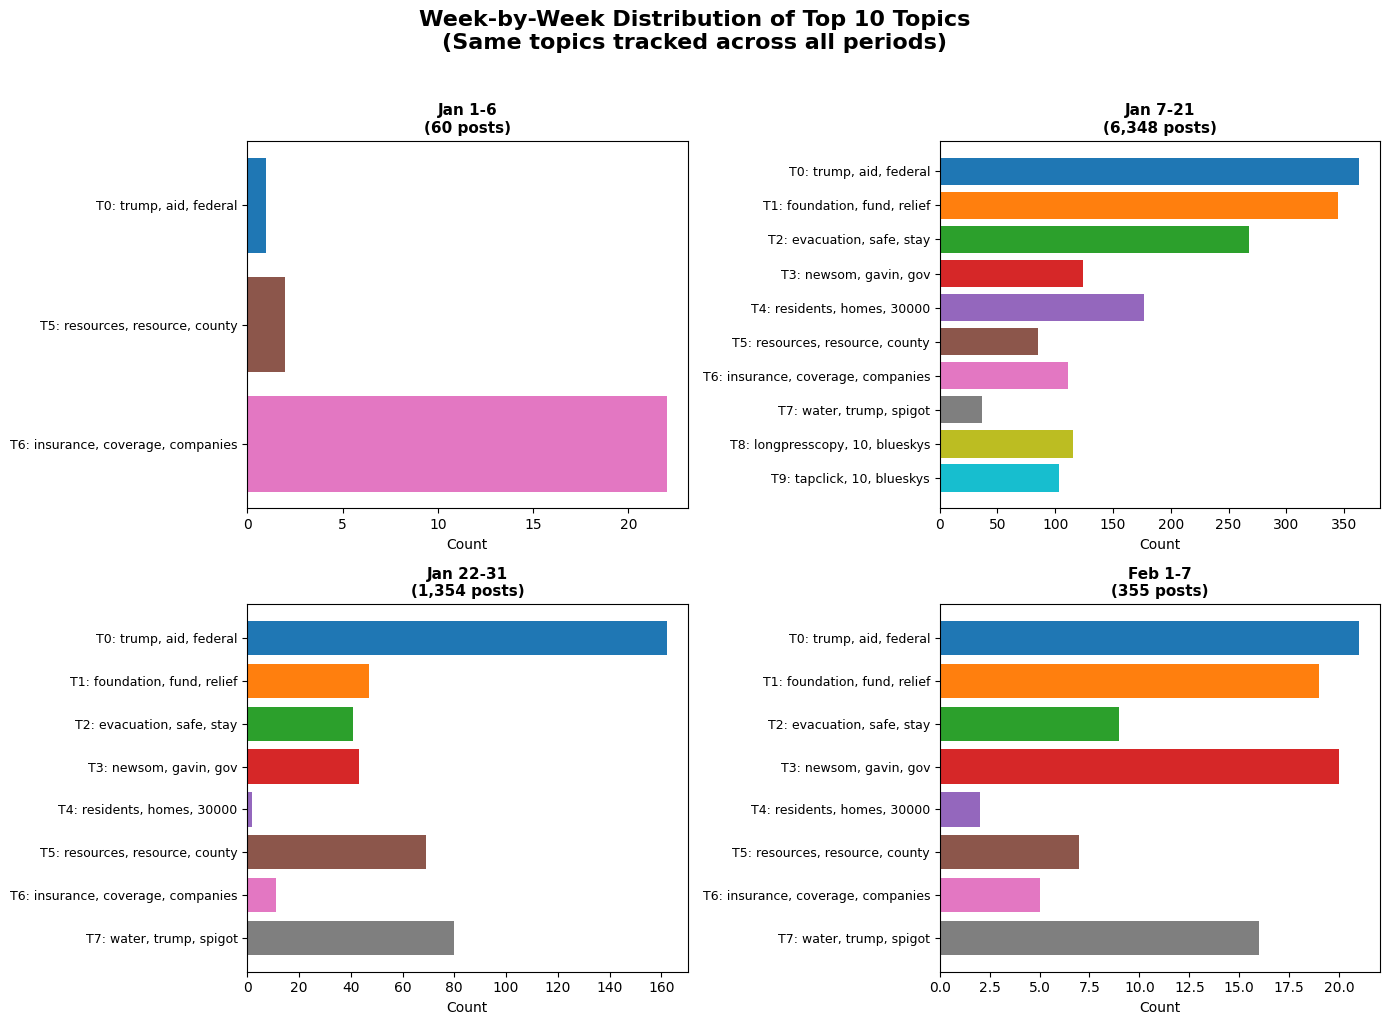

In [42]:
from matplotlib import pyplot as plt

# Create collage showing top 10 topics distribution per period (using overall model)
if topic_model_all is not None:
    # First, assign topics from overall model to all posts
    posts_with_overall_topics = posts[mask_all].copy()
    posts_with_overall_topics['topic'] = topics_all

    # Filter out topic -1 (outliers) and NaT dates
    posts_with_overall_topics = posts_with_overall_topics[posts_with_overall_topics['topic'] != -1]
    posts_with_overall_topics = posts_with_overall_topics.dropna(subset=['date_only'])

    # Get top 10 topics from overall model
    topic_info = topic_model_all.get_topic_info()
    valid_topics = topic_info[topic_info['Topic'] != -1].head(10)
    top_10_topic_ids = valid_topics['Topic'].tolist()

    # Create topic labels with top 3 words
    topic_labels_short = {}
    for t in top_10_topic_ids:
        words = topic_model_all.get_topic(t)
        if words:
            top_3_words = [w[0] for w in words[:3]]
            topic_labels_short[t] = f"T{t}: {', '.join(top_3_words)}"
        else:
            topic_labels_short[t] = f"Topic {t}"

    # Create a consistent color map for the top 10 topics
    n_topics = len(top_10_topic_ids)
    cmap_name = 'tab10' if n_topics <= 10 else 'tab20'
    cmap = plt.get_cmap(cmap_name)
    # avoid division by zero when n_topics == 1
    colors_list = [cmap(i / max(1, n_topics - 1)) for i in range(n_topics)]
    topic_color_map = {t: colors_list[i] for i, t in enumerate(top_10_topic_ids)}

    # Create 2x2 subplot layout for 4 periods
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (label, (start, end)) in enumerate(periods.items()):
        ax = axes[idx]

        # Filter posts for this period
        mask_period = (posts_with_overall_topics['date_only'] >= start) & \
                      (posts_with_overall_topics['date_only'] <= end)
        period_posts = posts_with_overall_topics[mask_period]

        if len(period_posts) > 0:
            # Count topics in this period (only top 10)
            topic_counts = period_posts[period_posts['topic'].isin(top_10_topic_ids)]['topic'].value_counts()

            # Ensure all top 10 topics are represented and preserve top_10_topic_ids order
            counts = [topic_counts.get(t, 0) for t in top_10_topic_ids]
            labels_all = [topic_labels_short[t] for t in top_10_topic_ids]

            # Only show topics with counts > 0, keep consistent colors by topic id
            non_zero = [(t, label, c) for t, label, c in zip(top_10_topic_ids, labels_all, counts) if c > 0]
            if non_zero:
                ids, labels, counts = zip(*non_zero)
                colors = [topic_color_map[t] for t in ids]

                bars = ax.barh(range(len(labels)), counts, color=colors)
                ax.set_yticks(range(len(labels)))
                ax.set_yticklabels(labels, fontsize=9)
                ax.invert_yaxis()
                ax.set_xlabel("Count", fontsize=10)
            else:
                ax.text(0.5, 0.5, "No matching topics", ha="center", va="center", fontsize=12)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

        ax.set_title(f"{label}\n({period_counts[label]:,} posts)", fontsize=11, fontweight="bold")

    plt.suptitle("Week-by-Week Distribution of Top 10 Topics\n(Same topics tracked across all periods)", 
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("weekly_topics_collage.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

_**Fig. 4:** Detailed results of the BERTopic analysis for the California wildfires discourse. Top 8 topics with their characteristic words across the 4 periods._

### Post Categorization

We utilized **Zero-Shot Classification** to determine the functional intent of posts without requiring a labeled training set.

* **Model:** `facebook/bart-large-mnli` (NLI-based classification).
* **Candidate Labels:** *information, opinion, action, emotion-related*.
* **Process:** The model computes the semantic similarity between the post text and these labels to assign a primary category.
* **Analysis:** This enables us to quantify the shift from information sharing (early stage) to action/mobilization (recovery stage).

In [ ]:
from transformers import pipeline
import matplotlib.pyplot as plt
import pandas as pd
from preprocess_data import preprocess_posts_and_interactions

posts, _ = preprocess_posts_and_interactions("../data/bluesky/posts_all.jsonl", "../data/bluesky/interactions_all.jsonl")
posts['date'] = pd.to_datetime(posts['created_at'], utc=True, errors='coerce').dt.date

# --- Subset the data to 200 posts ---
posts_subset = posts.sample(n=min(200, len(posts)), random_state=42)

# --- Define the periods ---
periods = {
    "Jan 1–6": (pd.to_datetime("2025-01-01").date(), pd.to_datetime("2025-01-06").date()),
    "Jan 7–21": (pd.to_datetime("2025-01-07").date(), pd.to_datetime("2025-01-21").date()),
    "Jan 22–31": (pd.to_datetime("2025-01-22").date(), pd.to_datetime("2025-01-31").date()),
    "Feb 1–7": (pd.to_datetime("2025-02-01").date(), pd.to_datetime("2025-02-07").date())
}

# --- Initialize the zero-shot classifier ---
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0) # Use GPU if available, can take time
labels = ["information", "opinion", "action", "emotion-related"]

# --- Classify posts ---
def classify_post(text):
    result = classifier(text, candidate_labels=labels)
    return result['labels'][0]  # Take the label with the highest score

posts_subset['category'] = posts_subset['text'].apply(classify_post)

# --- Group by period ---
# --- Group by period ---
data_rows = []
for period_name, (start, end) in periods.items():
    mask = (posts_subset['date'] >= start) & (posts_subset['date'] <= end)
    period_data = posts_subset.loc[mask]
    
    if period_data.empty:
        print(f"No posts for period: {period_name}")
        continue
    
    category_counts = period_data['category'].value_counts(normalize=True)  # Normalize to get proportions
    for category, proportion in category_counts.items():
        data_rows.append({'Period': period_name, 'Category': category, 'Proportion': proportion})

# --- Create a DataFrame for visualization ---
df_summary = pd.DataFrame(data_rows)

# Ensure all periods and categories are represented, even if proportions are 0
df_summary = df_summary.pivot_table(index='Period', columns='Category', values='Proportion', fill_value=0)
df_summary = df_summary.reindex(index=periods.keys(), columns=labels, fill_value=0)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

df_summary.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', edgecolor='black')

ax.set_title("Proportions of Post Categories Across Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Period", fontsize=12)
ax.set_ylabel("Proportion", fontsize=12)
ax.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("posts_by_primary_category.png")
plt.show()

## Sentiment analysis

### Sentiment Analysis with VADER

To quantify public sentiment, we utilized **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, a lexicon and rule-based sentiment analysis tool specifically attuned to sentiments expressed in social media.

* **Scoring:** For each post, VADER computes a **compound score** ranging from -1 (most extreme negative) to +1 (most extreme positive), along with separate probabilities for positive, neutral, and negative sentiment.
* **Aggregation:** We aggregated these scores daily to track the temporal evolution of collective sentiment (`mean_compound`) alongside the volume of discourse (`post_count`) throughout the crisis.

In [43]:
def add_vader_daily_sentiment(posts: pd.DataFrame):
    """
    Adds VADER sentiment (neg, neu, pos, compound) to posts and computes daily averages + post counts.

    Returns:
        posts: original posts with 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound', 'date'
        daily_sentiment: DataFrame with columns ['date', 'mean_neg', 'mean_neu', 'mean_pos', 'mean_compound', 'post_count']
    """
    analyzer = SentimentIntensityAnalyzer()

    # ---------- sentiment ----------
    vader_scores = posts['clean_text'].apply(lambda t: analyzer.polarity_scores(t))
    posts['sentiment_neg'] = vader_scores.apply(lambda x: x['neg'])
    posts['sentiment_neu'] = vader_scores.apply(lambda x: x['neu'])
    posts['sentiment_pos'] = vader_scores.apply(lambda x: x['pos'])
    posts['sentiment_compound'] = vader_scores.apply(lambda x: x['compound'])

    # ---------- convert timestamps ----------
    posts['date'] = pd.to_datetime(posts['created_at'], utc=True, errors='coerce').dt.date
    posts = posts.dropna(subset=['date']).reset_index(drop=True)

    # ---------- daily stats ----------
    daily_sentiment = posts.groupby('date').agg(
        mean_neg=('sentiment_neg', 'mean'),
        mean_neu=('sentiment_neu', 'mean'),
        mean_pos=('sentiment_pos', 'mean'),
        mean_compound=('sentiment_compound', 'mean'),
        post_count=('sentiment_compound', 'size')
    ).reset_index()

    return posts, daily_sentiment

# --- usage ---
posts_with_sentiment, daily_sentiment = add_vader_daily_sentiment(posts)
print(daily_sentiment.head())

         date  mean_neg  mean_neu  mean_pos  mean_compound  post_count
0  2025-01-01  0.007625  0.943750  0.048625       0.096312           8
1  2025-01-02  0.127111  0.806111  0.066778      -0.190900           9
2  2025-01-03  0.085000  0.764000  0.151200       0.148910          10
3  2025-01-04  0.140538  0.743923  0.115538      -0.044000          13
4  2025-01-05  0.107200  0.861200  0.031600      -0.236180           5


### Analysis of the posts from Jan 23rd

This was the day with the lowest overall sentiment, so we examined both the most negative posts and posts with average sentiment.

In [44]:
# ---------------------------
# Select posts from Jan 23
# ---------------------------
target_date = pd.to_datetime("2025-01-23").date()
day_posts = posts_with_sentiment[posts_with_sentiment['date'] == target_date]

if len(day_posts) == 0:
    print("No posts found on Jan 23.")
else:
    # Most negative post
    most_negative = day_posts.loc[day_posts['sentiment_compound'].idxmin()]

    # Find the post closest to the mean sentiment for Jan 23
    mean_sentiment = day_posts['sentiment_compound'].mean()
    closest_to_mean = day_posts.loc[(day_posts['sentiment_compound'] - mean_sentiment).abs().idxmin()]

    print("\n=== MOST NEGATIVE POST (Jan 23) ===")
    print("Score:", most_negative['sentiment_compound'])
    print("Text:", most_negative['clean_text'])

    print("\n=== AVERAGE POST (Closest to Mean Sentiment, Jan 23) ===")
    print("Mean sentiment for day:", mean_sentiment)
    print("Score:", closest_to_mean['sentiment_compound'])
    print("Text:", closest_to_mean['clean_text'])


=== MOST NEGATIVE POST (Jan 23) ===
Score: -0.911
Text: absolutely pathetic. he’s threatening withhold wildfire aid unless california bows demands. .bsky.social don’t dare give monster. choosing look away simply pay attention fuck. you.

=== AVERAGE POST (Closest to Mean Sentiment, Jan 23) ===
Mean sentiment for day: -0.2440854838709677
Score: -0.25
Text: mandatory evacuation order fire today. street going gridlocked. seems like winds blowing west away here. california burning arsonists work unfortunately.


### Combining post frequency and sentiment data with the NASA dataset

Index(['uri', 'cid', 'created_at', 'indexed_at', 'author_did', 'author_handle',
       'text', 'langs', 'reply_to', 'quoted', 'like_count', 'repost_count',
       'clean_text', 'sentiment', 'community', 'topic_overall', 'date_only',
       'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound',
       'date'],
      dtype='object')


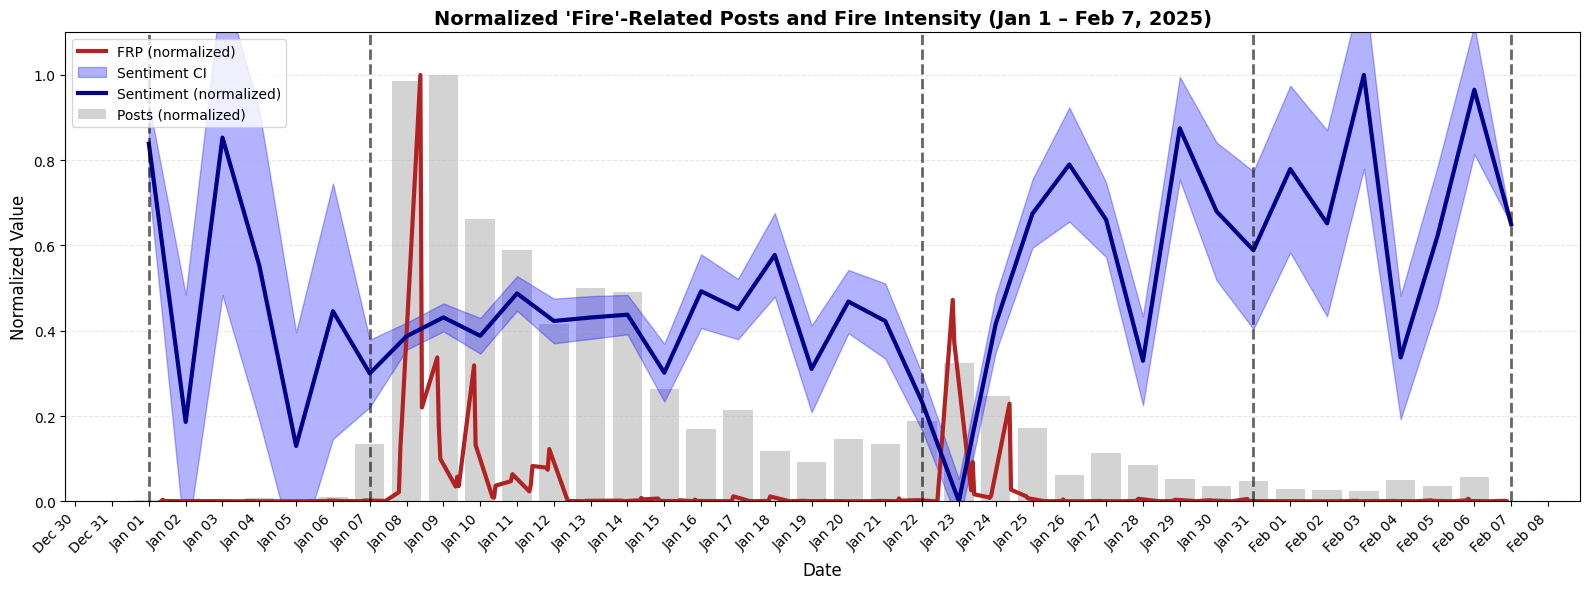

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# ---------------------------
# Define start and end dates
# ---------------------------
start_date = pd.Timestamp("2025-01-01", tz='UTC')
end_date   = pd.Timestamp("2025-02-07", tz='UTC')

# ---------------------------
# Load fire detection data
# ---------------------------
fire_data = pd.read_csv('https://raw.githubusercontent.com/Stonej29/02805/main/Project/data/nasa/combined_fire_detections.csv')
fire_data['datetime'] = pd.to_datetime(fire_data['datetime'], utc=True)
fire_data['hour'] = fire_data['datetime'].dt.floor('h')
fire_data = fire_data[(fire_data['hour'] >= start_date) & (fire_data['hour'] <= end_date)]

fire_by_hour = fire_data.groupby('hour').agg({
    'frp': 'sum',          # Total fire radiative power
    'brightness': 'count'  # Number of detections
}).reset_index()
fire_by_hour.columns = ['hour', 'total_frp', 'detection_count']

# ---------------------------
# Load Bluesky posts data
# ---------------------------
posts['indexed_at'] = pd.to_datetime(posts['indexed_at'], utc=True)
posts = posts[(posts['indexed_at'] >= start_date) & (posts['indexed_at'] <= end_date)]
posts['date'] = posts['indexed_at'].dt.date
posts_by_day = posts.groupby('date').size().reset_index(name='post_count')

# ---------------------------
# Prepare daily sentiment (VADER already computed)
# ---------------------------
# Assume daily_sentiment DataFrame exists: columns ['date', 'mean_compound']
# Also assume we have per-post sentiment to compute SEM
print(posts.columns)
if 'sentiment_compound' in posts.columns:
    # Compute mean and SEM per day
    sentiment_stats = posts.groupby('date')['sentiment_compound'].agg(['mean','std','count']).reset_index()
    sentiment_stats['sem'] = sentiment_stats['std'] / np.sqrt(sentiment_stats['count'])
else:
    # fallback if daily_sentiment only
    sentiment_stats = daily_sentiment.copy()
    sentiment_stats['sem'] = 0

# Reindex to include all days
all_days = pd.date_range(start=start_date.date(), end=end_date.date(), freq='D')
sentiment_stats = sentiment_stats.set_index('date').reindex(all_days).rename_axis('date').reset_index()
sentiment_stats['mean'] = sentiment_stats['mean'].fillna(0)
sentiment_stats['sem'] = sentiment_stats['sem'].fillna(0)

# Normalize mean sentiment for plotting
sentiment_stats['sentiment_norm'] = (
    (sentiment_stats['mean'] - sentiment_stats['mean'].min()) /
    (sentiment_stats['mean'].max() - sentiment_stats['mean'].min())
)
sentiment_stats['sem_norm'] = sentiment_stats['sem'] / (sentiment_stats['mean'].max() - sentiment_stats['mean'].min())

# ---------------------------
# Prepare fires metrics and normalize
# ---------------------------
fire_by_hour['total_frp_norm'] = (fire_by_hour['total_frp'] - fire_by_hour['total_frp'].min()) / \
                                 (fire_by_hour['total_frp'].max() - fire_by_hour['total_frp'].min())

# Normalize posts for histogram
posts_by_day['posts_norm'] = (posts_by_day['post_count'] - posts_by_day['post_count'].min()) / \
                             (posts_by_day['post_count'].max() - posts_by_day['post_count'].min())

# ---------------------------
# Plotting
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# Histogram: normalized posts per day (gray background)
ax.bar(posts_by_day['date'], posts_by_day['posts_norm'], width=0.8,
       color='darkgray', alpha=0.5, label='Posts (normalized)')

# FRP normalized line
ax.plot(fire_by_hour['hour'], fire_by_hour['total_frp_norm'], color='firebrick', linewidth=3,
        marker=None, label='FRP (normalized)')

# Sentiment confidence band
upper = sentiment_stats['sentiment_norm'] + sentiment_stats['sem_norm']
lower = sentiment_stats['sentiment_norm'] - sentiment_stats['sem_norm']

ax.fill_between(sentiment_stats['date'], lower, upper,
                color='blue', alpha=0.3, label='Sentiment CI')

# Sentiment line
ax.plot(sentiment_stats['date'], sentiment_stats['sentiment_norm'],
        color='darkblue', linewidth=3, label='Sentiment (normalized)')

# Add vertical lines for key dates
key_dates = [pd.Timestamp("2025-01-01"), pd.Timestamp("2025-01-07"), 
             pd.Timestamp("2025-01-22"), pd.Timestamp("2025-01-31"), 
             pd.Timestamp("2025-02-07")]
for date in key_dates:
    ax.axvline(x=date.normalize(), color='black', linestyle='--', alpha=0.6, linewidth=2)

# X-axis formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Labels and legend
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Value', fontsize=12)
ax.set_ylim(0,1.1)
ax.set_title("Normalized 'Fire'-Related Posts and Fire Intensity (Jan 1 – Feb 7, 2025)",
             fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

_**Fig. 5:** Temporal co-evolution of fire intensity, public attention, and sentiment (Jan 1 -- Feb 7, 2025). All metrics are min-max normalized to a [0, 1] scale for comparative visualization. Gray bars represent the daily volume of fire-related Bluesky posts (public attention). The red line tracks the total daily Fire Radiative Power (FRP) derived from NASA detection data (physical intensity). The blue line indicates the mean daily VADER sentiment compound score, with the shaded region representing the standard error of the mean (SEM)Vertical dashed lines demarcate the four periods used in the study._

### Viral Content and Emotional Correlation

We examined the interplay between post virality and emotional content to test the "polarization" hypothesis.

* **Virality Analysis:** Posts were ranked by repost count to identify the most widely disseminated content, revealing a prevalence of factual information over emotional outrage.
* **Sentiment-Virality Correlation:** We computed the correlation between **repost count** and **absolute sentiment intensity** (VADER) to determine if emotional volatility drives propagation.
* **Emotional Homophily:** To detect echo chambers, we calculated the correlation between the sentiment of **original posts** and their corresponding **replies**, assessing whether users primarily interact with content matching their emotional state.

In [46]:
# Print top 5 most reposted posts with author information and date
top_reposts = interactions[interactions['edge'] == 'repost']
top_reposts = top_reposts.groupby('dst_uri').size().reset_index(name='repost_count')
top_reposts = top_reposts.sort_values(by='repost_count', ascending=False).head(5)

for idx, row in top_reposts.iterrows():
    post_id = row['dst_uri']
    repost_count = row['repost_count']
    post_info = posts.loc[posts['uri'] == post_id, ['clean_text', 'author_handle', 'date']].values

    if len(post_info) > 0:
        post_text, author_handle, post_date = post_info[0]
        date_str = str(post_date) if not pd.isna(post_date) else "Unknown date"
        print(f"\n=== TOP REPOSTED POST (Reposts: {repost_count}) by {author_handle} ===")
        print("Date:", date_str)
        print("Text:", post_text)


=== TOP REPOSTED POST (Reposts: 14478) by georebekah.bsky.social ===
Date: 2025-01-08
Text: abc, nbc cbs dedicated 16 minutes airtime last night california wildfires without mentioning climate change. since news failed job, here's short summary role climate change wildfire risk: www.noaa.gov/noaa-wildfir...

=== TOP REPOSTED POST (Reposts: 3526) by patriottakes.bsky.social ===
Date: 2025-01-10
Text: 44 republicans voted forest management wildfire prevention december funds allow states like california create barriers stop spread fires

=== TOP REPOSTED POST (Reposts: 3425) by artcandee.bsky.social ===
Date: 2025-01-13
Text: netflix donating $10 million california wildfire relief efforts.

=== TOP REPOSTED POST (Reposts: 3188) by astrokatie.com ===
Date: 2025-01-08
Text: psa friends california near fires: breathing wildfire smoke really bad (even it’s super thick are) face masks (n95, kn95, etc) help lot

=== TOP REPOSTED POST (Reposts: 2352) by governor.ca.gov ===
Date: 2025-01-12
Text

In [47]:
# Modify sentiment column before merging
posts['sentiment_strength'] = posts['sentiment_compound'].abs()

def compute_repost_correlation_strength(posts: pd.DataFrame, interactions: pd.DataFrame):
    # Count reposts
    reposts = interactions[interactions['edge'] == 'repost'].groupby('dst_uri').size().reset_index(name='repost_count')

    # Merge using sentiment_strength
    posts_with_reposts = posts[['uri', 'sentiment_strength']].merge(
        reposts,
        left_on='uri',
        right_on='dst_uri',
        how='inner'
    )

    if len(posts_with_reposts) > 0:
        correlation = posts_with_reposts[['sentiment_strength', 'repost_count']].corr().iloc[0, 1]
        print(f"Correlation between sentiment *strength* and reposts: {correlation:.4f}")
        print(f"Sample size: {len(posts_with_reposts)} posts with reposts")
        return correlation, posts_with_reposts
    else:
        print("No posts with reposts found")
        return None, None

sentiment_strength_corr, posts_repost_data_strength = compute_repost_correlation_strength(posts, interactions)

Correlation between sentiment *strength* and reposts: 0.0033
Sample size: 2444 posts with reposts


In [48]:
# Find correlation between post sentiment and sentiment in replies to those posts
post_replies = interactions[interactions['edge'] == 'reply'].copy()

# Merge post sentiment into replies
post_replies = post_replies.merge(
    posts[['uri', 'sentiment_compound']].rename(columns={'sentiment_compound': 'post_sentiment'}),
    left_on='dst_uri', right_on='uri', how='left'
)

# Classify reply sentiment using VADER
analyzer = SentimentIntensityAnalyzer()
post_replies['reply_sentiment'] = post_replies['reply_text'].apply(
    lambda x: analyzer.polarity_scores(x)['compound'] if pd.notna(x) else None
)

# Remove rows with missing sentiment values
post_replies_valid = post_replies.dropna(subset=['post_sentiment', 'reply_sentiment'])

# Compute correlation
if len(post_replies_valid) > 0:
    correlation = post_replies_valid[['post_sentiment', 'reply_sentiment']].corr().iloc[0, 1]
    print(f"\nCorrelation between post sentiment and reply sentiment: {correlation:.4f}")
    print(f"Sample size: {len(post_replies_valid)} replies with valid sentiment")
else:
    print("No valid sentiment pairs found")


Correlation between post sentiment and reply sentiment: 0.1967
Sample size: 8913 replies with valid sentiment


### Emotion Classification

To analyze the emotional tone of the discourse, we employed a pre-trained **DistilRoBERTa** model fine-tuned on emotion datasets.

* **Model:** `j-hartmann/emotion-english-distilroberta-base`
* **Taxonomy:** Classifies posts into 7 discrete emotions: *anger, disgust, fear, joy, neutral, sadness, surprise*.
* **Optimization:** Results are cached locally to avoid redundant computation.
* **Output:** A stacked bar chart visualizing how the emotional composition of the conversation evolved across the four crisis periods.

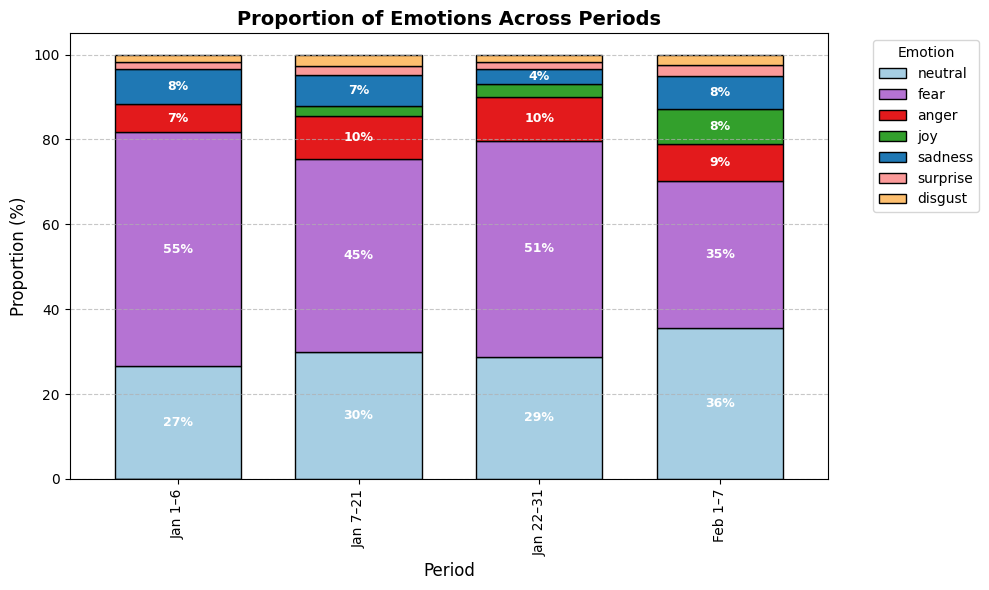

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- 1. ADD EMOTIONS TO PERIOD SUBSETS (if not already present) ---

CACHE_FILE = "emotion_cache.csv"

# Check if 'posts' variable exists, if not create a placeholder or skip
if 'posts' not in dir():
    print("Warning: 'posts' DataFrame not found. Please ensure it's defined in a previous cell.")
    posts = pd.DataFrame()

# A. Try to load from cache first
if len(posts) > 0 and 'emotions' not in posts.columns and os.path.exists(CACHE_FILE):
    print(f"Loading emotions from {CACHE_FILE}...")
    cached_df = pd.read_csv(CACHE_FILE)
    # Merge emotions back into 'posts' using the unique URI
    posts = posts.merge(cached_df[['uri', 'emotions']], on='uri', how='left')

# B. If 'emotions' is STILL missing (cache didn't exist or didn't cover these posts), run the model
if 'emotions' not in posts.columns or posts['emotions'].isnull().any():
    print("Cache not found or incomplete. Running emotion classification...")
    from transformers import pipeline
    
    # Run the model
    emotion_clf = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)
    
    # Fill only missing emotions (in case cache was partial, though usually it's all or nothing)
    mask_missing = posts['emotions'].isnull() if 'emotions' in posts.columns else [True] * len(posts)
    
    # Apply model (this is the slow part)
    # Note: If 'emotions' column doesn't exist yet, we create it
    if 'emotions' not in posts.columns:
        posts['emotions'] = None
        
    posts.loc[mask_missing, 'emotions'] = posts.loc[mask_missing, 'text'].apply(
        lambda x: max(emotion_clf(x)[0], key=lambda d: d['score'])['label']
    )
# --- 2. PREPARE THE DATA ---

data_rows = []

# Define time ranges for grouping posts
time_ranges_dict = {
    "Jan 1–6": (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-01-06")),
    "Jan 7–21": (pd.Timestamp("2025-01-07"), pd.Timestamp("2025-01-21")),
    "Jan 22–31": (pd.Timestamp("2025-01-22"), pd.Timestamp("2025-01-31")),
    "Feb 1–7": (pd.Timestamp("2025-02-01"), pd.Timestamp("2025-02-07"))
}

# Convert posts date column to datetime if it's not already
posts['date'] = pd.to_datetime(posts['date'], errors='coerce')

# Group posts by time period and count emotions
for period_name, (start, end) in time_ranges_dict.items():
    period_posts = posts[(posts['date'] >= start) & (posts['date'] <= end)]
    if len(period_posts) > 0 and 'emotions' in period_posts.columns:
        counts = period_posts['emotions'].value_counts()
        for emotion, count in counts.items():
            data_rows.append({'Period': period_name, 'Emotion': emotion, 'Count': count})

df_summary = pd.DataFrame(data_rows)

# Handle case where df_summary is empty
if len(df_summary) == 0:
    print("Warning: No emotion data found for the time periods. Check your 'posts' DataFrame and date formatting.")

# --- Prepare pivot table with percentages (assuming df_summary is ready) ---
emotion_order = ["neutral", "fear", "anger", "joy", "sadness", "surprise", "disgust"]
time_ranges = ["Jan 1–6", "Jan 7–21", "Jan 22–31", "Feb 1–7"]
color_map = {
    "neutral": "#a6cee3", "fear": "#b573d3", "anger": "#e31a1c",
    "joy": "#33a02c", "sadness": "#1f78b4", "surprise": "#fb9a99", "disgust": "#fdbf6f"
}

pivot_df = df_summary.pivot_table(index='Period', columns='Emotion', values='Count', fill_value=0)
pivot_df = pivot_df.reindex(index=time_ranges, columns=emotion_order, fill_value=0)
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# --- Plotting stacked bar ---
fig, ax = plt.subplots(figsize=(10, 6))

colors_list = [color_map[e] for e in emotion_order]

pivot_pct.plot(kind='bar', stacked=True, ax=ax, color=colors_list, edgecolor='black', width=0.7)

# --- Aesthetics ---
ax.set_title("Proportion of Emotions Across Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Period", fontsize=12)
ax.set_ylabel("Proportion (%)", fontsize=12)
ax.legend(title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Optional: bar labels for percentages > threshold ---
for c in ax.containers:
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.savefig("emotions_by_period_stacked.png")
plt.show()


_**Fig. 6:** Temporal evolution of sentiment on Bluesky (Jan 1--Feb 7, 2025). $\textit{Fear}$ (purple) dominates active phases (peak $55\%$), receding to $35\%$ in the final week as $\textit{Neutral}$ (light blue) and $\textit{Joy}$ (green) rise, signaling emotional recovery_